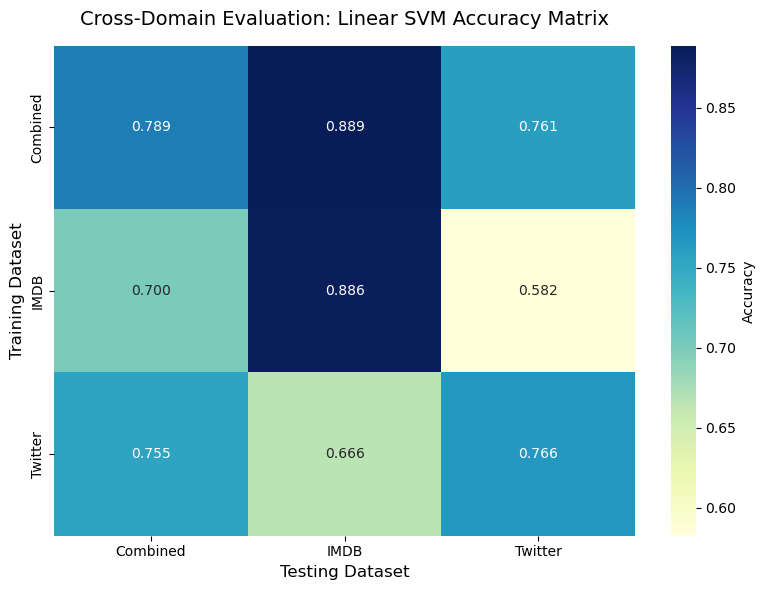

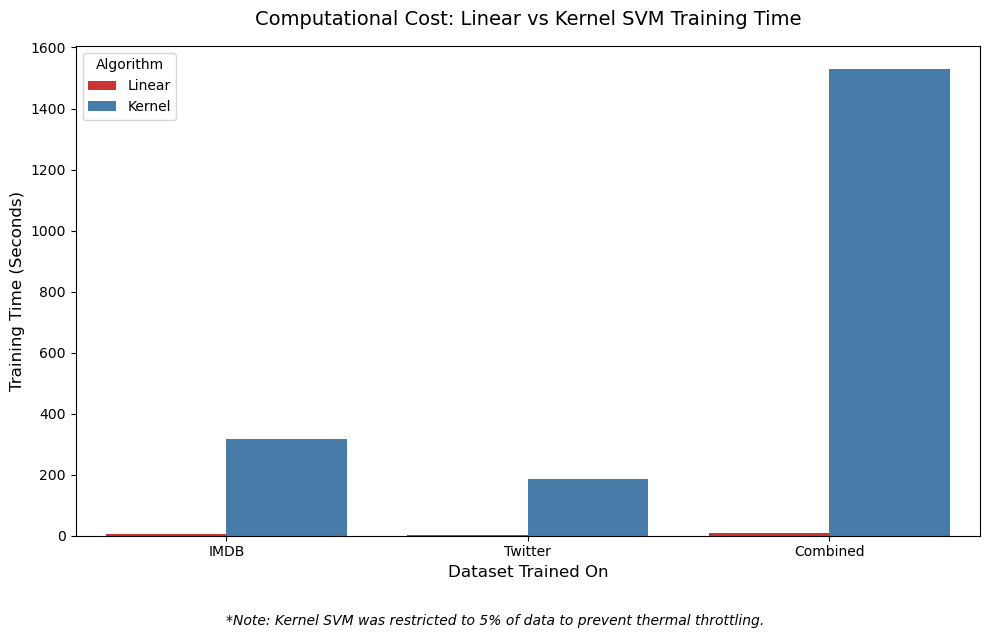

Cross-domain evaluation graphs generated and saved to the 'outputs' folder!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder for saving graphs
os.makedirs('../outputs', exist_ok=True)

# Load the metrics we just generated
df_metrics = pd.read_csv('../outputs/model_metrics.csv')

# Filter to only look at the Linear Models for the Accuracy Heatmap (cleaner visualization)
df_linear = df_metrics[df_metrics['Algorithm'] == 'Linear']

# Pivot the data to create a matrix: Rows = Trained On, Columns = Tested On
heatmap_data = df_linear.pivot(index='Trained_On', columns='Tested_On', values='Accuracy')

# ---------------------------------------------------------
# Graph 1: The Cross-Domain Evaluation Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Accuracy'})
plt.title("Cross-Domain Evaluation: Linear SVM Accuracy Matrix", fontsize=14, pad=15)
plt.ylabel("Training Dataset", fontsize=12)
plt.xlabel("Testing Dataset", fontsize=12)

# Fix layout and save
plt.tight_layout()
plt.savefig('../outputs/cross_domain_heatmap.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# Graph 2: Training Time Comparison (Linear vs Kernel)
# ---------------------------------------------------------
# We only need one row per model for training time (since it's the same regardless of test set)
df_time = df_metrics.drop_duplicates(subset=['Algorithm', 'Trained_On'])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_time, x='Trained_On', y='Training_Time_Sec', hue='Algorithm', palette='Set1')
plt.title("Computational Cost: Linear vs Kernel SVM Training Time", fontsize=14, pad=15)
plt.ylabel("Training Time (Seconds)", fontsize=12)
plt.xlabel("Dataset Trained On", fontsize=12)

# Add a text note about the Kernel data percentage
plt.figtext(0.5, -0.05, "*Note: Kernel SVM was restricted to 5% of data to prevent thermal throttling.", 
            ha="center", fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('../outputs/training_time_comparison.png', bbox_inches="tight", dpi=300)
plt.show()

print("Cross-domain evaluation graphs generated and saved to the 'outputs' folder!")